In [1]:
from graph_tool.all import *
import numpy as np

# Susceptible: 0
# Infectado: 1
# Debilitado: 2
# Recuperado: 3

In [2]:
new_states = np.random.choice([0, 1, 2], size=20, p=[0.8, 0.1, 0.1])

In [3]:
X = [1,2,3]
def test(y):
    X.append(y)

In [4]:
test(1)

In [5]:
X

[1, 2, 3, 1]

In [2]:
def swir(n, z, rho0, kappa, mu, eta):
    pER = z/n
    ss = 1 - mu - kappa
    ww = 1 - eta
    
    # inicialización del grafo erdos renyi
    g = random_graph(n, lambda: np.random.poisson((n-1) * pER), directed=False, model="erdos")

    # declarar una propiedad llamada "estado" que va a guardar el estado de cada nodo
    estado = g.new_vertex_property("short")

    # Asignar a todos los nodos el estado susceptible
    estado.get_array()[:] = 0

    # Generar rho0*n índices aleatorios
    infected_index = np.random.choice(np.arange(0, n), size=int(n*rho0), replace=False)

    # Actualizar el estado de rho0*n nodos al estado infectado
    estado.get_array()[infected_index] = 1

    # Iterador que contiene los nodos infectados
    I = [g.vertex(i) for i in infected_index]
    
    def reaction(vertex):
        """
        Función que realiza un paso de tiempo para un nodo infectado:
        vertex es un nodo en estado infectado.
        """
        # inicia una lista que guarda los nodos que serán infectados
        new_infected = []
        # actualiza el estado del nodo actual infectado a recuperado
        estado[vertex] = 3
        # obtiene los vecinos del nodo infectado
        vecinos = vertex.out_neighbors()
        # obtiene un iterador de los nodos en estado susceptible
        S = (v for v in vecinos if estado[v]==0)
        # obtiene los vecinos del nodo infectado otra vez porque vecinos es un generador
        vecinos = vertex.out_neighbors()
        # obtiene un iterador de los nodos en estado debilitado
        W = (v for v in vecinos if estado[v]==2)
        # itera sobre los susceptibles
        for s in S:
            # calcula el nuevo estado del nodo susceptible
            new_state = np.random.choice([0, 1, 2], size=1, p=[ss, kappa, mu])[0]
            # asigna el nuevo estado del nodo susceptible
            estado[s] = new_state
            # revisa si el nuevo estado es infectado para añadirlo a la lista que guarda la lista de los infectados
            if new_state == 1:
                new_infected.append(s)
        # itera sobre los debilitados
        for w in W:
            #calcula el nuevo estado del nodo debilitado
            new_state = np.random.choice([2, 1], size=1, p=[ww, eta])[0]
            #asigna el nuevo estado del nodo debilitado
            estado[w] = new_state
            # revisa si el nuevo estado es infectado para añadirlo a la lista que guarda la lista de los infectados
            if new_state == 1:
                new_infected.append(w)
        # devuelve los vecinos que se infectaron
        return new_infected
    while I:
        # inicia una lista que guarda los nodos que serán infectados en el paso de tiempo n
        new_infected_n = []
        # itera sobre los nodos infectados
        for i in I:
            # hace que el nodo infectado reaccione con sus vecinos
            ni = reaction(i)
            # agrega los vecinos infectados a la lista de los nuevos infectados
            new_infected_n.append(ni)
        # actualiza la lista de los nuevos infectados para el paso de tiempo n+1
        I = [s for sublist in new_infected_n for s in sublist]
        np.random.shuffle(I)
    return estado.get_array()

def swir2(n, z, rho0, kappa, mu, eta):
    pER = z/n
    ss = 1 - mu - kappa
    ww = 1 - eta
    
    # inicialización del grafo erdos renyi
    g = random_graph(n, lambda: np.random.poisson((n-1) * pER), directed=False, model="erdos")

    # declarar una propiedad llamada "estado" que va a guardar el estado de cada nodo
    estado = g.new_vertex_property("short")

    # Asignar a todos los nodos el estado susceptible
    estado.get_array()[:] = 0

    # Generar rho0*n índices aleatorios
    infected_index = np.random.choice(np.arange(0, n), size=int(n*rho0), replace=False)

    # Actualizar el estado de rho0*n nodos al estado infectado
    estado.get_array()[infected_index] = 1

    # Iterador que contiene los nodos infectados
    I = [g.vertex(i) for i in infected_index]
    
    def reaction(vertex):
        """
        Función que realiza un paso de tiempo para un nodo infectado:
        vertex es un nodo en estado infectado.
        """
        # inicia una lista que guarda los nodos que serán infectados
        new_infected = []
        # actualiza el estado del nodo actual infectado a recuperado
        estado[vertex] = 3
        # obtiene los vecinos del nodo infectado
        vecinos = vertex.out_neighbors()
        S = np.array([g.vertex_index[v] for v in vecinos if estado[v]==0]).astype(int)
        #print(S)
        vecinos = vertex.out_neighbors()
        W = np.array([g.vertex_index[v] for v in vecinos if estado[v]==2]).astype(int)
        #print(W)
        new_states = np.random.choice([0, 1, 2], size=S.size, p=[ss, kappa, mu])
        #print(new_states)
        estado.get_array()[S] = new_states
        new_infected = [g.vertex(i) for i in S[new_states==1]]
        new_states = np.random.choice([2, 1], size=W.size, p=[ww, eta])
        estado.get_array()[W] = new_states
        new_infected += [g.vertex(i) for i in W[new_states==1]]
        #print(len(new_infected))
        # devuelve los vecinos que se infectaron
        return new_infected
    while I:
        #print(len(I))
        # inicia una lista que guarda los nodos que serán infectados en el paso de tiempo n
        new_infected_n = []
        # itera sobre los nodos infectados
        for i in I:
            # hace que el nodo infectado reaccione con sus vecinos
            ni = reaction(i)
            # agrega los vecinos infectados a la lista de los nuevos infectados
            new_infected_n.append(ni)
        # actualiza la lista de los nuevos infectados para el paso de tiempo n+1
        I = [s for sublist in new_infected_n for s in sublist]
        np.random.shuffle(I)
    return estado.get_array()

def swir3(n, z, rho0, kappa, mu, eta):
    pER = z/n
    ss = 1 - mu - kappa
    ww = 1 - eta
    
    # inicialización del grafo erdos renyi
    g = random_graph(n, lambda: np.random.poisson((n-1) * pER), directed=False, model="erdos")

    # declarar una propiedad llamada "estado" que va a guardar el estado de cada nodo
    estado = g.new_vertex_property("short")

    # Asignar a todos los nodos el estado susceptible
    estado.get_array()[:] = 0

    # Generar rho0*n índices aleatorios
    infected_index = np.random.choice(np.arange(0, n), size=int(n*rho0), replace=False)

    # Actualizar el estado de rho0*n nodos al estado infectado
    estado.get_array()[infected_index] = 1

    # Iterador que contiene los nodos infectados
    I = [g.vertex(i) for i in infected_index]
    
    def reaction(vertex):
        """
        Función que realiza un paso de tiempo para un nodo infectado:
        vertex es un nodo en estado infectado.
        """
        # inicia una lista que guarda los nodos que serán infectados
        new_infected = []
        # actualiza el estado del nodo actual infectado a recuperado
        estado[vertex] = 3
        # obtiene los vecinos del nodo infectado
        vecinos = vertex.out_neighbors()
        S = np.array([g.vertex_index[v] for v in vecinos if estado[v]==0]).astype(int)
        #print(S)
        vecinos = vertex.out_neighbors()
        W = np.array([g.vertex_index[v] for v in vecinos if estado[v]==2]).astype(int)
        #print(W)
        new_states = np.random.choice([0, 1, 2], size=S.size, p=[ss, kappa, mu])
        #print(new_states)
        estado.get_array()[S] = new_states
        new_infected = [g.vertex(i) for i in S[new_states==1]]
        new_states = np.random.choice([2, 1], size=W.size, p=[ww, eta])
        estado.get_array()[W] = new_states
        new_infected += [g.vertex(i) for i in W[new_states==1]]
        #print(len(new_infected))
        # devuelve los vecinos que se infectaron
        return new_infected
    while I:
        #print(len(I))
        # inicia una lista que guarda los nodos que serán infectados en el paso de tiempo n
        new_infected_n = []
        # itera sobre los nodos infectados
        for i in I:
            # hace que el nodo infectado reaccione con sus vecinos
            ni = reaction(i)
            # agrega los vecinos infectados a la lista de los nuevos infectados
            new_infected_n.append(ni)
        # actualiza la lista de los nuevos infectados para el paso de tiempo n+1
        I = [s for sublist in new_infected_n for s in sublist]
        np.random.shuffle(I)
    return estado.get_array()

In [54]:
s1 = swir(10000, 8, 2e-3, 0.2, 0.2, 0.5)
m1 = np.count_nonzero(s1 == 3)
s2 = swir2(10000, 8, 2e-3, 0.2, 0.2, 0.5)
m2 = np.count_nonzero(s2 == 3)
print(m1,m2)

4788 86


In [55]:
%timeit swir(10000, 8, 2e-3, 0.2, 0.2, 0.5)

3.88 s ± 19 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [56]:
%timeit swir2(10000, 8, 2e-3, 0.2, 0.2, 0.5)

2.58 s ± 15.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [3]:
from pathos.multiprocessing import ProcessingPool as Pool
import tqdm

In [5]:
N = 100000
def worker_function(kappa, N):
    return swir2(N, 8, 0.00747762, kappa, kappa, 0.5)

kappa_range = (np.linspace(-1, 1, 30))**3
max_new = 0.108021+0.003
min_new = 0.108021-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new
#kappa_range = np.linspace(0.07, 0.118, 20)

#results = []
#for kappa in tqdm.tqdm(kappa_range):
#    results.append(worker_function(kappa, N))

with Pool(4) as pool:
    results = list(tqdm.tqdm(pool.imap(worker_function, kappa_range, (N for n in range(N))), total=kappa_range.size))

100%|██████████| 30/30 [00:52<00:00,  2.55s/it]


In [6]:
ms = []
for r in results:
    m = np.count_nonzero(r == 3)/N
    ms.append(m)

In [7]:
import matplotlib.pyplot as plt

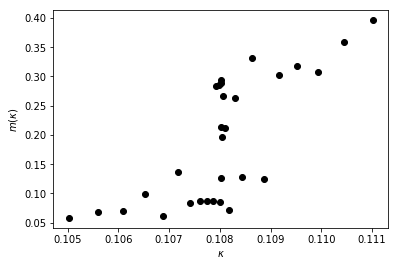

In [8]:
plt.plot(kappa_range, ms, 'ko')
plt.ylabel(r'$m(\kappa)$')
plt.xlabel(r'$\kappa$')
plt.savefig('100k_nodes.png')
plt.show()

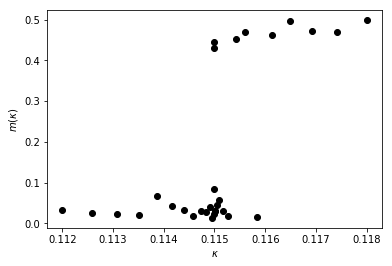

In [17]:
plt.plot(kappa_range, ms, 'ko')
plt.ylabel(r'$m(\kappa)$')
plt.xlabel(r'$\kappa$')
plt.savefig('100k_nodes.png')
plt.show()

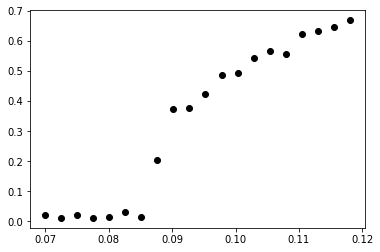

In [10]:
plt.plot(kappa_range, ms, 'ko')

In [32]:
from time import time

Ns = [int(n) for n in np.geomspace(100, 100000, 7)]
times = []
for n in Ns:
    t0 = time()
    est = swir(n, 8, 0.1, 0.2, 0.1, 0.1)
    t = time()-t0
    print(t)
    times.append(t)

0.020766258239746094
0.07914113998413086
0.26991915702819824
0.8224437236785889
2.5991108417510986
8.290196895599365
26.28043270111084


In [34]:
z = np.polyfit(np.log(Ns), np.log(times), 1)
p = np.poly1d(z)
print(np.exp(p(np.log(40e6)))/60/24)

8.762609772619713
